<a href="https://colab.research.google.com/github/EEHZYDHAVE/behavioural-credit-signals-for-fintech/blob/main/Expanding_Access_to_Credit_Invisible_Segment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 2 Version 2 Full Behavioral Signal Evaluation**
## **Installments + POS Cash Balance + Credit Card Balance vs Demographics**

#### What This Notebook Does

This is a standalone notebook. It loads all data from scratch, performs all
necessary cleaning, and runs the full analysis independently. No prior notebook
needs to be open or connected for this to work.

#### Where We Are in the Larger Project

Part 1 established that traditional demographic proxies are weak but real
predictors of NPL outcomes among thin-file borrowers. The best single
demographic variable scored 0.0806. The demographic composite scored 0.1156.
Even combined demographics left 80% of the riskiest group repaying.

Version 1 of Part 2 tested behavioral signals from installment repayment data
only. The behavioral composite scored 0.0680, competitive with mid-tier
demographics but below the demographic composite. Every behavioral feature
outperformed income amount, and the top three behavioral signals sat directly
in the middle of the combined ranking, ahead of gender, education, and family
status.

But Version 1 was an incomplete behavioral picture. It used one source out of
three available behavioral datasets.

#### What Version 2 Adds

Version 2 builds the full behavioral profile by incorporating all three
behavioral data sources available in this dataset:

- **installments_payments.csv**: structured loan repayment behavior
- **POS_CASH_balance.csv**: point-of-sale and cash loan account health
- **credit_card_balance.csv**: revolving credit management behavior

Together these three sources cover structured repayment, loan account status
trajectory, and discretionary credit management, the complete behavioral
picture this dataset allows.

#### The Central Question

Does the full behavioral profile, across all three data sources, outperform
traditional demographic proxies in predicting NPL outcomes among thin-file
borrowers?

#### The Benchmarks to Beat

| Benchmark | Value |
|---|---|
| Best individual demographic signal | 0.0806 |
| Demographic composite score | 0.1156 |
| Demographic quintile spread | 8.67 percentage points |
| Version 1 behavioral composite | 0.0680 |

## **1 Importing the Necessary Librabry**

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
# Download the dataset

dataset_url = 'https://www.kaggle.com/competitions/home-credit-default-risk/data'

%time
od.download(dataset_url)

CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 8.34 µs
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: davidelijahdroidnet
Your Kaggle Key: ··········


100%|██████████| 688M/688M [00:07<00:00, 97.1MB/s]



Extracting archive ./home-credit-default-risk/home-credit-default-risk.zip to ./home-credit-default-risk


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr

## **2 Loading the dataset & Data Cleaning**

In [ ]:
# ============================================================
# CELL 2 — DATA LOADING
# ============================================================

data_dir = 'home-credit-default-risk'

print("Loading datasets...\n")

app = pd.read_csv(f'{data_dir}/application_train.csv')
inst = pd.read_csv(f'{data_dir}/installments_payments.csv')
pos = pd.read_csv(f'{data_dir}/POS_CASH_balance.csv')
cc = pd.read_csv(f'{data_dir}/credit_card_balance.csv')

print(f"application_train:     {app.shape[0]:,} rows x {app.shape[1]} columns")
print(f"installments_payments: {inst.shape[0]:,} rows x {inst.shape[1]} columns")
print(f"POS_CASH_balance:      {pos.shape[0]:,} rows x {pos.shape[1]} columns")
print(f"credit_card_balance:   {cc.shape[0]:,} rows x {cc.shape[1]} columns")

# ============================================================
# CELL 3 — APPLICATION DATA CLEANING
# Replicating the exact cleaning steps from Part 1
# ============================================================

print("\nCleaning application data...\n")

# Convert DAYS_BIRTH to AGE in years
app['AGE'] = (-app['DAYS_BIRTH'] / 365).astype(int)

# Convert DAYS_EMPLOYED to EMPLOYMENT_YEARS
# Replace placeholder value 365243 with 0
app['EMPLOYMENT_YEARS'] = (-app['DAYS_EMPLOYED'] / 365)
app['EMPLOYMENT_YEARS'] = app['EMPLOYMENT_YEARS'].apply(
    lambda x: 0 if x < 0 else x
)

# Fill OCCUPATION_TYPE missing values with Unknown
app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].fillna('Unknown')

# Fill minor missing values
app['AMT_ANNUITY'] = app['AMT_ANNUITY'].fillna(app['AMT_ANNUITY'].median())
app['AMT_GOODS_PRICE'] = app['AMT_GOODS_PRICE'].fillna(app['AMT_GOODS_PRICE'].median())
app['CNT_FAM_MEMBERS'] = app['CNT_FAM_MEMBERS'].fillna(app['CNT_FAM_MEMBERS'].median())
app['NAME_TYPE_SUITE'] = app['NAME_TYPE_SUITE'].fillna('Unknown')
app['OWN_CAR_AGE'] = app['OWN_CAR_AGE'].fillna(0)
app['DEF_30_CNT_SOCIAL_CIRCLE'] = app['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(0)
app['DEF_60_CNT_SOCIAL_CIRCLE'] = app['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(0)
app['OBS_30_CNT_SOCIAL_CIRCLE'] = app['OBS_30_CNT_SOCIAL_CIRCLE'].fillna(0)
app['OBS_60_CNT_SOCIAL_CIRCLE'] = app['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(0)

# Keep only our 26 locked feature columns from Part 1
cols_to_keep = [
    'SK_ID_CURR', 'TARGET',
    # Pure demographics
    'AGE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_INCOME_TYPE',
    'AMT_INCOME_TOTAL', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    # Loan request characteristics
    'NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    # Soft stability signals
    'EMPLOYMENT_YEARS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE', 'REGION_RATING_CLIENT', 'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH', 'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
]

app = app[cols_to_keep].copy()

print(f"Application data cleaned.")
print(f"Shape: {app.shape[0]:,} rows x {app.shape[1]} columns")
print(f"Missing values: {app.isnull().sum().sum()}")

# ============================================================
# CELL 4 — QUICK DATA OVERVIEW
# ============================================================

print("\n=== DATASET OVERVIEW ===\n")
print(f"{'Dataset':<30} {'Rows':>12} {'Columns':>10} {'Unique Borrowers':>18}")
print("-" * 72)
print(f"{'application_train':<30} {app.shape[0]:>12,} {app.shape[1]:>10} {app['SK_ID_CURR'].nunique():>18,}")
print(f"{'installments_payments':<30} {inst.shape[0]:>12,} {inst.shape[1]:>10} {inst['SK_ID_CURR'].nunique():>18,}")
print(f"{'POS_CASH_balance':<30} {pos.shape[0]:>12,} {pos.shape[1]:>10} {pos['SK_ID_CURR'].nunique():>18,}")
print(f"{'credit_card_balance':<30} {cc.shape[0]:>12,} {cc.shape[1]:>10} {cc['SK_ID_CURR'].nunique():>18,}")

print(f"\nOverall NPL rate: {app['TARGET'].mean()*100:.2f}%")
print(f"\nData loading and cleaning complete. Ready for analysis.")

Loading datasets...

application_train:     307,511 rows x 122 columns
installments_payments: 13,605,401 rows x 8 columns
POS_CASH_balance:      10,001,358 rows x 8 columns
credit_card_balance:   3,840,312 rows x 23 columns

Cleaning application data...

Application data cleaned.
Shape: 307,511 rows x 26 columns
Missing values: 0

=== DATASET OVERVIEW ===

Dataset                                Rows    Columns   Unique Borrowers
------------------------------------------------------------------------
application_train                   307,511         26            307,511
installments_payments            13,605,401          8            339,587
POS_CASH_balance                 10,001,358          8            337,252
credit_card_balance               3,840,312         23            103,558

Overall NPL rate: 8.07%

Data loading and cleaning complete. Ready for analysis.


### What stands out immediately:

Installments and POS both cover around 337,000-339,000 unique borrowers, more than the 307,511 in application_train. That is expected because those files include borrowers from previous applications not just the current one. Our overlap investigation will sort out exactly who maps to our working population.<br><br>

Credit card is the interesting one, only 103,558 unique borrowers have credit card records. That is roughly one third of the full population. So not everyone has revolving credit history with Home Credit, which makes sense, credit cards are a specific product not everyone uses.
The application data is clean, 26 columns, zero missing values, exactly as expected.

### **2.1 Population Overlap Investigation**

In [ ]:
# ============================================================
# CELL 5 — POPULATION OVERLAP INVESTIGATION
# All three behavioral sources vs application_train
# ============================================================

app_borrowers = set(app['SK_ID_CURR'].unique())
inst_borrowers = set(inst['SK_ID_CURR'].unique())
pos_borrowers = set(pos['SK_ID_CURR'].unique())
cc_borrowers = set(cc['SK_ID_CURR'].unique())

# Overlap with application_train
inst_overlap = app_borrowers.intersection(inst_borrowers)
pos_overlap = app_borrowers.intersection(pos_borrowers)
cc_overlap = app_borrowers.intersection(cc_borrowers)

# Borrowers with at least one behavioral source
any_behavioral = inst_overlap.union(pos_overlap).union(cc_overlap)

# Borrowers with all three sources
all_three = inst_overlap.intersection(pos_overlap).intersection(cc_overlap)

# Borrowers with installments + POS only
inst_pos_only = inst_overlap.intersection(pos_overlap) - cc_overlap

# Borrowers with no behavioral source
no_behavioral = app_borrowers - any_behavioral

print("=== POPULATION OVERLAP — ALL THREE SOURCES ===\n")
print(f"{'Source':<45} {'Borrowers':>10} {'% of Total':>12}")
print("-" * 70)
print(f"{'Total in application_train':<45} {len(app_borrowers):>10,} {'100.0%':>12}")
print(f"{'With installment records':<45} {len(inst_overlap):>10,} {len(inst_overlap)/len(app_borrowers)*100:>11.1f}%")
print(f"{'With POS records':<45} {len(pos_overlap):>10,} {len(pos_overlap)/len(app_borrowers)*100:>11.1f}%")
print(f"{'With credit card records':<45} {len(cc_overlap):>10,} {len(cc_overlap)/len(app_borrowers)*100:>11.1f}%")
print(f"{'With at least one behavioral source':<45} {len(any_behavioral):>10,} {len(any_behavioral)/len(app_borrowers)*100:>11.1f}%")
print(f"{'With all three sources':<45} {len(all_three):>10,} {len(all_three)/len(app_borrowers)*100:>11.1f}%")
print(f"{'With installments + POS only (no CC)':<45} {len(inst_pos_only):>10,} {len(inst_pos_only)/len(app_borrowers)*100:>11.1f}%")
print(f"{'With no behavioral source at all':<45} {len(no_behavioral):>10,} {len(no_behavioral)/len(app_borrowers)*100:>11.1f}%")

# NPL rates by overlap group
app_any = app[app['SK_ID_CURR'].isin(any_behavioral)]
app_all_three = app[app['SK_ID_CURR'].isin(all_three)]
app_no_behav = app[~app['SK_ID_CURR'].isin(any_behavioral)]

print(f"\n=== NPL RATES BY OVERLAP GROUP ===\n")
print(f"{'Group':<45} {'NPL Rate':>10}")
print("-" * 57)
print(f"{'Full dataset':<45} {app['TARGET'].mean()*100:>9.2f}%")
print(f"{'Any behavioral source':<45} {app_any['TARGET'].mean()*100:>9.2f}%")
print(f"{'All three sources':<45} {app_all_three['TARGET'].mean()*100:>9.2f}%")
print(f"{'No behavioral source':<45} {app_no_behav['TARGET'].mean()*100:>9.2f}%")

# ============================================================
# LOCK WORKING POPULATION
# Borrowers with at least one behavioral source
# ============================================================
working_population = any_behavioral

app_v2 = app[app['SK_ID_CURR'].isin(working_population)].copy()
inst_v2 = inst[inst['SK_ID_CURR'].isin(working_population)].copy()
pos_v2 = pos[pos['SK_ID_CURR'].isin(working_population)].copy()
cc_v2 = cc[cc['SK_ID_CURR'].isin(working_population)].copy()

print(f"\n=== WORKING POPULATION LOCKED ===\n")
print(f"Borrowers in Version 2 analysis: {len(app_v2):,}")
print(f"NPL rate:                        {app_v2['TARGET'].mean()*100:.2f}%")
print(f"\nBehavioral records available:")
print(f"  Installment records:  {len(inst_v2):,}")
print(f"  POS records:          {len(pos_v2):,}")
print(f"  Credit card records:  {len(cc_v2):,}")

=== POPULATION OVERLAP — ALL THREE SOURCES ===

Source                                         Borrowers   % of Total
----------------------------------------------------------------------
Total in application_train                       307,511       100.0%
With installment records                         291,643        94.8%
With POS records                                 289,444        94.1%
With credit card records                          86,905        28.3%
With at least one behavioral source              292,286        95.0%
With all three sources                            84,055        27.3%
With installments + POS only (no CC)             204,956        66.6%
With no behavioral source at all                  15,225         5.0%

=== NPL RATES BY OVERLAP GROUP ===

Group                                           NPL Rate
---------------------------------------------------------
Full dataset                                       8.07%
Any behavioral source                     



#### Coverage Across All Three Behavioral Sources

| Source | Borrowers | % of Total |
|---|---|---|
| Total in application_train | 307,511 | 100.0% |
| With installment records | 291,643 | 94.8% |
| With POS records | 289,444 | 94.1% |
| With credit card records | 86,905 | 28.3% |
| With at least one behavioral source | 292,286 | 95.0% |
| With all three sources | 84,055 | 27.3% |
| With no behavioral source | 15,225 | 5.0% |

#### NPL Rates by Group

| Group | NPL Rate |
|---|---|
| Full dataset | 8.07% |
| Any behavioral source | 8.19% |
| All three sources | 8.58% |
| No behavioral source | 5.80% |

#### Working Population Decision

Our Version 2 working population is **292,286 borrowers**, everyone with at
least one behavioral source. This covers 95% of the full dataset and carries
an NPL rate of 8.19%, almost identical to the full dataset, confirming the
subset is representative and unbiased.

Installments and POS are the broad behavioral sources, covering over 94% of
borrowers each. Credit card is the narrow source, only 28.3% of borrowers
have revolving credit history with Home Credit, which reflects that credit
cards are a specific product not everyone uses.

Borrowers without credit card records will have their credit card behavioral
features filled with 0, meaning no revolving credit activity observed, which
is itself informative. Borrowers with no behavioral source at all, 15,225
borrowers or 5%, are excluded from Version 2.

#### Behavioral Records Available

| Source | Records |
|---|---|
| Installment records | 11,591,592 |
| POS records | 8,543,375 |
| Credit card records | 3,227,965 |
| **Total behavioral records** | **23,362,932** |

## **3.1 Feature Engineering**

In [ ]:
# ============================================================
# CELL 6 FEATURE ENGINEERING: INSTALLMENTS
# Same as Version 1
# ============================================================

print("Engineering installment features...\n")

inst_v2['DAYS_ENTRY_PAYMENT'] = inst_v2['DAYS_ENTRY_PAYMENT'].fillna(
    inst_v2['DAYS_INSTALMENT'] + 90
)
inst_v2['AMT_PAYMENT'] = inst_v2['AMT_PAYMENT'].fillna(0)

inst_v2['PAYMENT_DELAY'] = inst_v2['DAYS_ENTRY_PAYMENT'] - inst_v2['DAYS_INSTALMENT']
inst_v2['PAYMENT_RATIO'] = inst_v2['AMT_PAYMENT'] / (inst_v2['AMT_INSTALMENT'] + 1e-9)
inst_v2['PAYMENT_RATIO'] = inst_v2['PAYMENT_RATIO'].clip(upper=2.0)
inst_v2['UNDERPAID'] = (inst_v2['PAYMENT_RATIO'] < 0.95).astype(int)
inst_v2['PAID_LATE'] = (inst_v2['PAYMENT_DELAY'] > 1).astype(int)

def compute_delay_trend(group):
    if len(group) < 3:
        return 0
    correlation = group['NUM_INSTALMENT_NUMBER'].corr(group['PAYMENT_DELAY'])
    return correlation if not np.isnan(correlation) else 0

print("Computing installment delay trend...")
delay_trend = inst_v2.groupby('SK_ID_CURR').apply(
    compute_delay_trend, include_groups=False
).reset_index()
delay_trend.columns = ['SK_ID_CURR', 'DELAY_TREND']

inst_features = inst_v2.groupby('SK_ID_CURR').agg(
    INST_AVG_PAYMENT_DELAY   = ('PAYMENT_DELAY', 'mean'),
    INST_MAX_PAYMENT_DELAY   = ('PAYMENT_DELAY', 'max'),
    INST_STD_PAYMENT_DELAY   = ('PAYMENT_DELAY', 'std'),
    INST_LATE_PAYMENT_RATE   = ('PAID_LATE', 'mean'),
    INST_TOTAL_LATE_PAYMENTS = ('PAID_LATE', 'sum'),
    INST_AVG_PAYMENT_RATIO   = ('PAYMENT_RATIO', 'mean'),
    INST_MIN_PAYMENT_RATIO   = ('PAYMENT_RATIO', 'min'),
    INST_UNDERPAYMENT_RATE   = ('UNDERPAID', 'mean'),
    INST_TOTAL_UNDERPAYMENTS = ('UNDERPAID', 'sum'),
    INST_NUM_INSTALLMENTS    = ('PAYMENT_DELAY', 'count'),
).reset_index()

inst_features = inst_features.merge(delay_trend, on='SK_ID_CURR', how='left')
inst_features = inst_features.rename(columns={'DELAY_TREND': 'INST_DELAY_TREND'})
inst_features['INST_STD_PAYMENT_DELAY'] = inst_features[
    'INST_STD_PAYMENT_DELAY'].fillna(0)

print(f"Installment features: {inst_features.shape[1]-1} features for {len(inst_features):,} borrowers")

# ============================================================
# CELL 7 FEATURE ENGINEERING: POS CASH BALANCE
# ============================================================

print("\nEngineering POS features...\n")
print(f"POS columns: {list(pos_v2.columns)}")

# Overdue flag NAME_CONTRACT_STATUS indicates account status
pos_v2['IS_OVERDUE'] = (pos_v2['SK_DPD'] > 0).astype(int)
pos_v2['IS_SERIOUSLY_OVERDUE'] = (pos_v2['SK_DPD_DEF'] > 0).astype(int)

pos_features = pos_v2.groupby('SK_ID_CURR').agg(
    POS_AVG_DPD              = ('SK_DPD', 'mean'),
    POS_MAX_DPD              = ('SK_DPD', 'max'),
    POS_OVERDUE_RATE         = ('IS_OVERDUE', 'mean'),
    POS_SERIOUS_OVERDUE_RATE = ('IS_SERIOUSLY_OVERDUE', 'mean'),
    POS_TOTAL_OVERDUE_MONTHS = ('IS_OVERDUE', 'sum'),
    POS_NUM_MONTHS           = ('MONTHS_BALANCE', 'count'),
    POS_AVG_MONTHS_BALANCE   = ('CNT_INSTALMENT', 'mean'),
).reset_index()

print(f"POS features: {pos_features.shape[1]-1} features for {len(pos_features):,} borrowers")

# ============================================================
# CELL 8 FEATURE ENGINEERING: CREDIT CARD BALANCE
# ============================================================

print("\nEngineering credit card features...\n")
print(f"Credit card columns: {list(cc_v2.columns)}")

# Utilization rate balance used vs credit limit
cc_v2['UTILIZATION_RATE'] = cc_v2['AMT_BALANCE'] / (cc_v2['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-9)
cc_v2['UTILIZATION_RATE'] = cc_v2['UTILIZATION_RATE'].clip(upper=1.0)

# Minimum payment flag did they only pay the minimum?
cc_v2['PAID_MIN_ONLY'] = (
    cc_v2['AMT_PAYMENT_CURRENT'] <= cc_v2['AMT_INST_MIN_REGULARITY'] * 1.05
).astype(int)

# Overdue flag
cc_v2['IS_OVERDUE'] = (cc_v2['SK_DPD'] > 0).astype(int)
cc_v2['IS_SERIOUSLY_OVERDUE'] = (cc_v2['SK_DPD_DEF'] > 0).astype(int)

cc_features = cc_v2.groupby('SK_ID_CURR').agg(
    CC_AVG_UTILIZATION       = ('UTILIZATION_RATE', 'mean'),
    CC_MAX_UTILIZATION       = ('UTILIZATION_RATE', 'max'),
    CC_AVG_DPD               = ('SK_DPD', 'mean'),
    CC_MAX_DPD               = ('SK_DPD', 'max'),
    CC_OVERDUE_RATE          = ('IS_OVERDUE', 'mean'),
    CC_SERIOUS_OVERDUE_RATE  = ('IS_SERIOUSLY_OVERDUE', 'mean'),
    CC_MIN_PAYMENT_RATE      = ('PAID_MIN_ONLY', 'mean'),
    CC_NUM_MONTHS            = ('MONTHS_BALANCE', 'count'),
).reset_index()

print(f"Credit card features: {cc_features.shape[1]-1} features for {len(cc_features):,} borrowers")

# ============================================================
# CELL 9 MERGE ALL FEATURES TOGETHER
# ============================================================

print("\nMerging all features...\n")

app_v2 = app_v2.merge(inst_features, on='SK_ID_CURR', how='left')
app_v2 = app_v2.merge(pos_features, on='SK_ID_CURR', how='left')
app_v2 = app_v2.merge(cc_features, on='SK_ID_CURR', how='left')

# Fill missing behavioral features with 0
# Borrowers without credit card records get 0 no revolving activity observed
behavioral_all_cols = (
    [c for c in inst_features.columns if c != 'SK_ID_CURR'] +
    [c for c in pos_features.columns if c != 'SK_ID_CURR'] +
    [c for c in cc_features.columns if c != 'SK_ID_CURR']
)

app_v2[behavioral_all_cols] = app_v2[behavioral_all_cols].fillna(0)

print(f"=== MERGED DATASET CONFIRMATION ===\n")
print(f"Shape: {app_v2.shape[0]:,} rows x {app_v2.shape[1]} columns")
print(f"Borrowers: {len(app_v2):,}")
print(f"Missing values: {app_v2[behavioral_all_cols].isnull().sum().sum()}")
print(f"NPL rate: {app_v2['TARGET'].mean()*100:.2f}%")
print(f"\nFeature breakdown:")
print(f"  Demographic features:      26  (including SK_ID_CURR and TARGET)")
print(f"  Installment features:      {len([c for c in inst_features.columns if c != 'SK_ID_CURR'])}")
print(f"  POS features:              {len([c for c in pos_features.columns if c != 'SK_ID_CURR'])}")
print(f"  Credit card features:      {len([c for c in cc_features.columns if c != 'SK_ID_CURR'])}")
print(f"  Total behavioral features: {len(behavioral_all_cols)}")
print(f"\nAll columns: {list(app_v2.columns)}")

Engineering installment features...

Computing installment delay trend...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Installment features: 11 features for 291,643 borrowers

Engineering POS features...

POS columns: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']
POS features: 7 features for 289,444 borrowers

Engineering credit card features...

Credit card columns: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']
Credit card features: 8 features for 86,905 borrowers

Merging all features...

=== MERGED DATASET CONFIRMATION ===

Shape:

All three behavioral data sources have been processed and merged into a
single working dataset.

### Dataset Summary

| | |
|---|---|
| **Borrowers** | 292,286 |
| **Total columns** | 52 |
| **Missing values** | 0 |
| **NPL rate** | 8.19% |

### Feature Breakdown

| Source | Features | What They Capture |
|---|---|---|
| Installments | 11 | Payment timing, amounts, consistency, trend |
| POS Cash Balance | 7 | Account overdue frequency, days past due, activity |
| Credit Card | 8 | Utilization, overdue rates, minimum payment behavior |
| **Total Behavioral** | **26** | **Full behavioral profile** |
| Demographic | 24 | Static application characteristics |

### Notable Features Added vs Version 1

**From POS data:** How often a borrower's loan accounts fell overdue,
maximum days past due on any account, and how many months of account
history exist. These capture account-level health beyond just individual
payment timing.

**From credit card data:** Average and maximum credit utilization rate,
overdue and seriously overdue rates on revolving credit, minimum payment
behavior, and months of credit card history. Credit card behavior is
particularly informative because it reflects discretionary financial
management — active choices a borrower makes, not just scheduled
obligations.

> Version 1 used 11 behavioral features from one source. Version 2 uses
> 26 behavioral features across three sources — more than doubling the
> behavioral signal available for each borrower.

## **3 Signal Evaluation: Full Behavioral Profile vs Demographics**

#### What This Stage Does

This is the core comparison of Version 2 and the most important stage in the
entire project. We now run the same signal evaluation framework, identical
methodology, identical population, identical outcome variable, on all 26
behavioral features across all three sources and place them directly against
the 10 demographic variables.

Version 1 tested 11 behavioral features from installment data alone and the
behavioral composite scored 0.0680, competitive but below the demographic
composite of 0.1156. The question Version 2 answers is whether adding POS
and credit card behavioral data changes that verdict.

---

#### What Each Source Adds to the Behavioral Picture

**Installments, structured repayment behavior**
Does this borrower pay on time? Do they pay the full amount? Are their
habits getting better or worse over time? This is the foundation of the
behavioral profile and covers 94.8% of borrowers.

**POS Cash Balance, loan account health**
How often do this borrower's accounts fall overdue? How many days past due
do they go? How long is their account history? This captures account-level
financial stress beyond individual payment timing and covers 94.1% of
borrowers.

**Credit Card Balance, revolving credit management**
How much of their credit limit does this borrower use? Do they pay the
minimum or the full balance? How often do their credit accounts fall
overdue? Credit card behavior is one of the strongest behavioral predictors
in traditional credit scoring because it reflects active, discretionary
financial decisions — not just scheduled obligations. Covers 28.3% of
borrowers.

---

#### The Benchmarks

| Benchmark | Value |
|---|---|
| Demographic ceiling — best individual variable | 0.0801 |
| Demographic composite score | 0.1156 |
| Version 1 behavioral ceiling — best individual variable | 0.0713 |
| Version 1 behavioral composite score | 0.0680 |

For Version 2 to change the verdict, the full behavioral profile needs to
either produce individual signals above **0.0801** or a composite score
above **0.1156**, or both. If it closes the gap significantly without
crossing the line, that is still a meaningful finding about the value of
richer behavioral data.

=== BEHAVIORAL SIGNAL RANKING ALL 26 FEATURES ===

                    Variable Source  Signal Score Direction Significant
1     INST_LATE_PAYMENT_RATE   INST        0.0711  Positive         Yes
2     INST_UNDERPAYMENT_RATE   INST        0.0665  Positive         Yes
3     INST_AVG_PAYMENT_RATIO   INST        0.0606  Negative         Yes
4   POS_SERIOUS_OVERDUE_RATE    POS        0.0464  Positive         Yes
5     INST_MIN_PAYMENT_RATIO   INST        0.0461  Negative         Yes
6         CC_MAX_UTILIZATION     CC        0.0434  Positive         Yes
7        CC_MIN_PAYMENT_RATE     CC        0.0414  Positive         Yes
8             POS_NUM_MONTHS    POS        0.0365  Negative         Yes
9   INST_TOTAL_LATE_PAYMENTS   INST        0.0332  Positive         Yes
10  INST_TOTAL_UNDERPAYMENTS   INST        0.0308  Positive         Yes
11          POS_OVERDUE_RATE    POS        0.0301  Positive         Yes
12    INST_AVG_PAYMENT_DELAY   INST        0.0216  Positive         Yes
13     INST_N

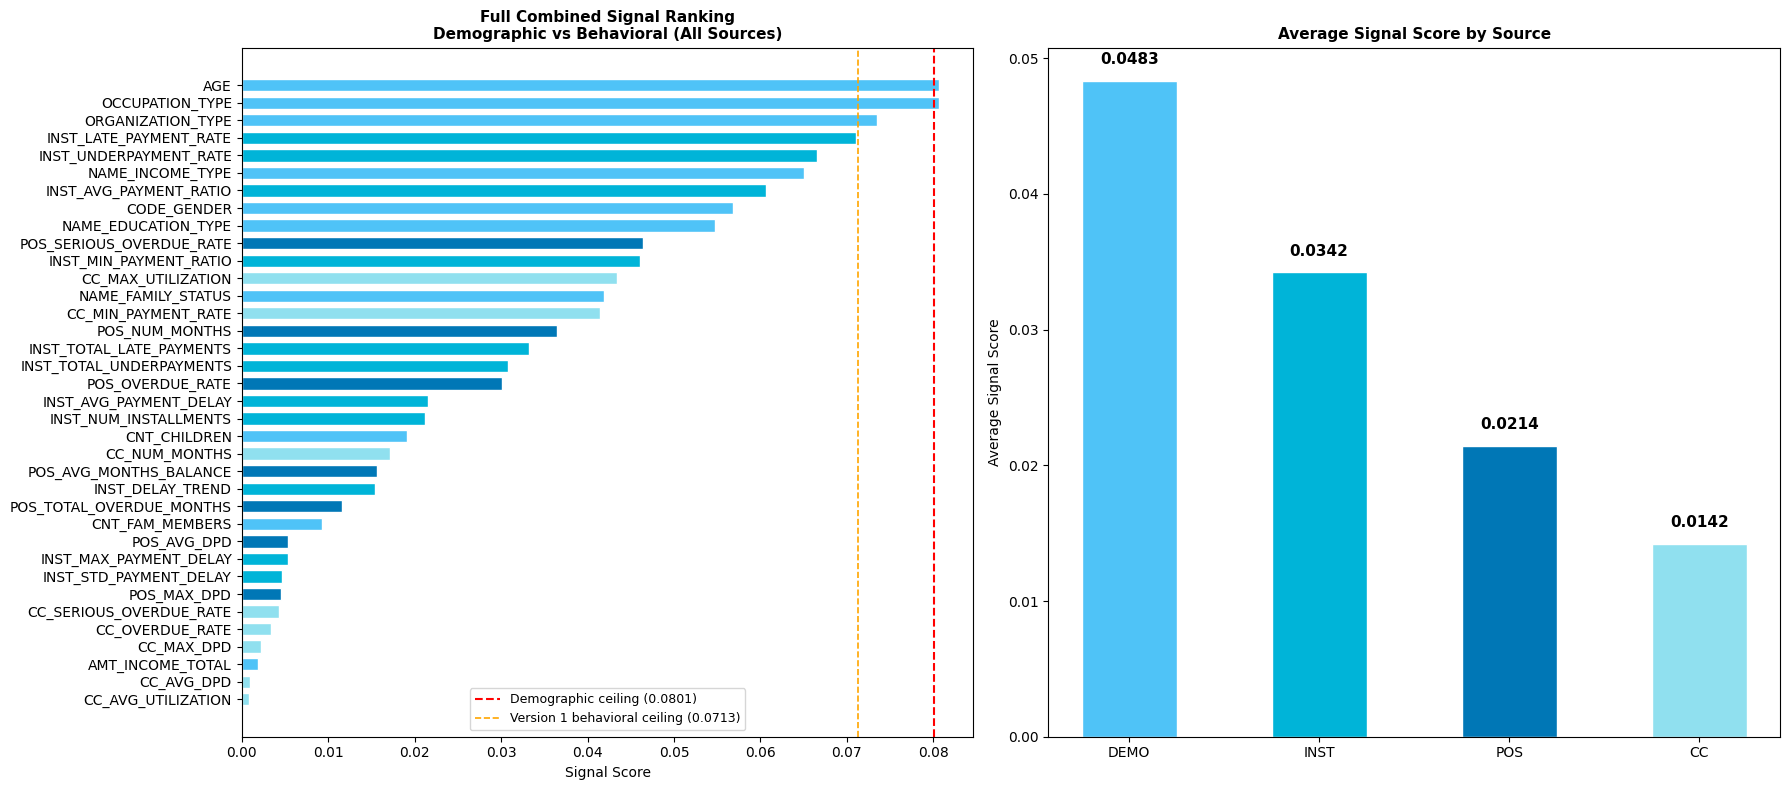

In [ ]:
# ============================================================
#  BEHAVIORAL SIGNAL EVALUATION: ALL 26 FEATURES
# Same methodology as Part 1 and Version 1
# ============================================================

from scipy import stats

behavioral_all_cols = [
    # Installment features
    'INST_AVG_PAYMENT_DELAY', 'INST_MAX_PAYMENT_DELAY', 'INST_STD_PAYMENT_DELAY',
    'INST_LATE_PAYMENT_RATE', 'INST_TOTAL_LATE_PAYMENTS', 'INST_AVG_PAYMENT_RATIO',
    'INST_MIN_PAYMENT_RATIO', 'INST_UNDERPAYMENT_RATE', 'INST_TOTAL_UNDERPAYMENTS',
    'INST_NUM_INSTALLMENTS', 'INST_DELAY_TREND',
    # POS features
    'POS_AVG_DPD', 'POS_MAX_DPD', 'POS_OVERDUE_RATE', 'POS_SERIOUS_OVERDUE_RATE',
    'POS_TOTAL_OVERDUE_MONTHS', 'POS_NUM_MONTHS', 'POS_AVG_MONTHS_BALANCE',
    # Credit card features
    'CC_AVG_UTILIZATION', 'CC_MAX_UTILIZATION', 'CC_AVG_DPD', 'CC_MAX_DPD',
    'CC_OVERDUE_RATE', 'CC_SERIOUS_OVERDUE_RATE', 'CC_MIN_PAYMENT_RATE',
    'CC_NUM_MONTHS'
]

# ============================================================
# STEP 1 BEHAVIORAL SIGNAL SCORES
# ============================================================
behavioral_results = []

for col in behavioral_all_cols:
    corr, p_value = stats.pointbiserialr(
        app_v2['TARGET'], app_v2[col]
    )
    behavioral_results.append({
        'Variable': col,
        'Source': col.split('_')[0],
        'Type': 'Behavioral',
        'Signal Score': round(abs(corr), 4),
        'Direction': 'Positive' if corr > 0 else 'Negative',
        'P_Value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

behav_df = pd.DataFrame(behavioral_results).sort_values(
    'Signal Score', ascending=False
).reset_index(drop=True)
behav_df.index += 1

print("=== BEHAVIORAL SIGNAL RANKING ALL 26 FEATURES ===\n")
print(behav_df[['Variable', 'Source', 'Signal Score',
                 'Direction', 'Significant']].to_string())

print(f"\nTop behavioral signal:    {behav_df.iloc[0]['Variable']} ({behav_df.iloc[0]['Signal Score']})")
print(f"Version 1 top signal:     LATE_PAYMENT_RATE (0.0713)")
print(f"Demographic ceiling:      0.0801")
print(f"\nBehavioral signals beating demographic ceiling (0.0801):")
beat = behav_df[behav_df['Signal Score'] > 0.0801]
print(beat[['Variable', 'Signal Score']].to_string() if len(beat) > 0 else "None")

# ============================================================
# STEP 2 DEMOGRAPHIC SIGNAL SCORES
# Re-run on Version 2 population for clean comparison
# ============================================================
demo_cols_cat = [
    'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE'
]
demo_cols_cont = [
    'AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'AMT_INCOME_TOTAL'
]

demo_results = []

for col in demo_cols_cat:
    contingency = pd.crosstab(app_v2[col], app_v2['TARGET'])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    n = len(app_v2)
    k = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k))
    demo_results.append({
        'Variable': col,
        'Source': 'DEMO',
        'Type': 'Demographic',
        'Signal Score': round(cramers_v, 4),
        'P_Value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

for col in demo_cols_cont:
    corr, p_value = stats.pointbiserialr(app_v2['TARGET'], app_v2[col])
    demo_results.append({
        'Variable': col,
        'Source': 'DEMO',
        'Type': 'Demographic',
        'Signal Score': round(abs(corr), 4),
        'P_Value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

demo_df = pd.DataFrame(demo_results).sort_values(
    'Signal Score', ascending=False
).reset_index(drop=True)
demo_df.index += 1

print("\n=== DEMOGRAPHIC SIGNAL RANKING VERSION 2 POPULATION ===\n")
print(demo_df[['Variable', 'Signal Score', 'Significant']].to_string())

# ============================================================
# STEP 3 FULL COMBINED RANKING
# ============================================================
combined_df = pd.concat([
    behav_df[['Variable', 'Source', 'Type', 'Signal Score', 'Significant']],
    demo_df[['Variable', 'Source', 'Type', 'Signal Score', 'Significant']]
]).sort_values('Signal Score', ascending=False).reset_index(drop=True)
combined_df.index += 1
combined_df.columns.name = None

print("\n=== FULL COMBINED RANKING ===\n")
print(combined_df.to_string())

# ============================================================
# STEP 4 SUMMARY STATISTICS
# ============================================================
print("\n=== SUMMARY COMPARISON ===\n")
print(f"{'Metric':<50} {'Demographic':>14} {'Behavioral':>14}")
print("-" * 80)
print(f"{'Best individual signal score':<50} {demo_df['Signal Score'].max():>14.4f} {behav_df['Signal Score'].max():>14.4f}")
print(f"{'Average signal score':<50} {demo_df['Signal Score'].mean():>14.4f} {behav_df['Signal Score'].mean():>14.4f}")
print(f"{'Weakest signal score':<50} {demo_df['Signal Score'].min():>14.4f} {behav_df['Signal Score'].min():>14.4f}")
print(f"{'Variables beating demographic ceiling (0.0801)':<50} {'N/A':>14} {len(behav_df[behav_df['Signal Score'] > 0.0801]):>14}")
print(f"{'Variables beating income amount':<50} {len(demo_df[demo_df['Signal Score'] > demo_df[demo_df['Variable']=='AMT_INCOME_TOTAL']['Signal Score'].values[0]]):>14} {len(behav_df[behav_df['Signal Score'] > demo_df[demo_df['Variable']=='AMT_INCOME_TOTAL']['Signal Score'].values[0]]):>14}")

# ============================================================
# STEP 5 VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Full combined ranking chart
colors = ['#4FC3F7' if t == 'Demographic' else
          '#00B4D8' if s == 'INST' else
          '#0077B6' if s == 'POS' else
          '#90E0EF'
          for t, s in zip(combined_df['Type'], combined_df['Source'])]

combined_sorted = combined_df.sort_values('Signal Score', ascending=True)
colors_sorted = ['#4FC3F7' if t == 'Demographic' else
                 '#00B4D8' if s == 'INST' else
                 '#0077B6' if s == 'POS' else
                 '#90E0EF'
                 for t, s in zip(combined_sorted['Type'], combined_sorted['Source'])]

axes[0].barh(combined_sorted['Variable'], combined_sorted['Signal Score'],
             color=colors_sorted, edgecolor='white', height=0.7)
axes[0].axvline(x=0.0801, color='red', linestyle='--',
                linewidth=1.5, label='Demographic ceiling (0.0801)')
axes[0].axvline(x=0.0713, color='orange', linestyle='--',
                linewidth=1.2, label='Version 1 behavioral ceiling (0.0713)')
axes[0].set_title('Full Combined Signal Ranking\nDemographic vs Behavioral (All Sources)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Signal Score')
axes[0].legend(fontsize=9)

# Source comparison average signal score by source
source_avg = combined_df.groupby('Source')['Signal Score'].mean().sort_values(ascending=False)
source_colors = {'DEMO': '#4FC3F7', 'INST': '#00B4D8', 'POS': '#0077B6', 'CC': '#90E0EF'}
axes[1].bar(source_avg.index, source_avg.values,
            color=[source_colors.get(s, '#888888') for s in source_avg.index],
            edgecolor='white', width=0.5)
axes[1].set_title('Average Signal Score by Source',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Average Signal Score')
for i, (source, val) in enumerate(source_avg.items()):
    axes[1].text(i, val + 0.001, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### **3. 1 Signal Evaluation Findings**

#### The Headline

Adding POS and credit card behavioral data did not push any individual
behavioral signal above the demographic ceiling of **0.0801**. The best
behavioral signal remains installment late payment rate at **0.0711**,
almost identical to Version 1's 0.0713. The demographic ceiling held.

But the individual signal scores are only part of the story.

---

#### Full Combined Ranking, Key Observations

The combined ranking of all 36 variables tells a more nuanced picture
than the headline suggests:

- Positions 1, 2, and 3 go to demographics, age, occupation type,
organization type
- Positions 4 and 5 go to behavioral, installment late payment rate
and underpayment rate
- Position 7 goes to behavioral, average payment ratio
- Positions 10, 12, and 14 go to behavioral, POS serious overdue rate,
credit card max utilization, and credit card minimum payment rate
- Income amount sits dead last at position 34, below 24 out of 26
behavioral features

Behavioral signals are woven throughout the middle of the ranking. They
are not trailing at the bottom, they are competing directly with
mid-tier demographics across the board.

---

#### What Each New Source Added

**POS Cash Balance** contributed meaningfully. POS serious overdue rate
scored **0.0464**, ranking 10th overall and outperforming family status,
children count, and family members count. How often a borrower's loan
accounts fall seriously overdue is more informative than several
demographic variables lenders regularly collect.

**Credit card** produced mixed results. Maximum utilization rate (0.0434)
and minimum payment rate (0.0414) both ranked in the top 15 overall,
these are strong signals. However average utilization (0.0008) and average
DPD (0.0009) scored near zero and are not statistically significant. This
is a zero-fill artifact, the 71.7% of borrowers with no credit card
records were filled with 0, which collapses the average distributions and
masks the signal. Maximum and rate-based measures are more robust to this
because they capture extremes and proportions rather than raw averages.

---

#### Summary Comparison Version 2 vs Demographics

| Metric | Demographic | Behavioral |
|---|---|---|
| Best individual signal score | 0.0806 | 0.0711 |
| Average signal score | 0.0484 | 0.0246 |
| Weakest signal score | 0.0019 | 0.0008 |
| Variables beating demographic ceiling | N/A | 0 |
| Variables beating income amount | 9 of 10 | 24 of 26 |

The behavioral average score (0.0246) is lower than Version 1 (0.0347)
because 15 new features were added — several of which are weaker signals
affected by the zero-fill issue for credit card non-holders. The top
behavioral signals held their ground. The new additions brought the
average down.

---

#### Version 1 vs Version 2 Did Adding More Data Help?

| | Version 1 | Version 2 |
|---|---|---|
| Behavioral features | 11 | 26 |
| Best behavioral signal | 0.0713 | 0.0711 |
| Behavioral average score | 0.0347 | 0.0246 |

Adding more behavioral sources did not improve the top signal score.
The installment features remain the strongest behavioral predictors.
POS added useful mid-range signals. Credit card added some value at
the top but introduced noise at the bottom through the zero-fill
limitation. The composite comparison in the next stage will determine
whether combining all 26 features together produces a stronger
overall score than combining the top demographic variables.

## **4 Composite Signal Comparison**

#### What This Stage Does

Individual signal scores test each variable in isolation. This stage
tests what happens when the best behavioral signals and the best
demographic signals are each combined into a composite risk score and
compared head to head, the way credit decisions are actually made.

This is the final and most important comparison in the project. It
answers the central question directly: when you put the full behavioral
profile against the full demographic profile, which one draws a sharper
line between borrowers who will default and those who will not?

---

#### The Approach

We build two composite risk scores per borrower, one from the top
demographic variables and one from the top behavioral variables, using
the same methodology from Version 1 with one important addition. For
the behavioral composite we now have three sources to draw from. We
will use the top performing features from each source to ensure the
composite represents the full behavioral picture rather than being
dominated by installment features alone.

**Demographic composite:** Top 5 demographic variables by signal score,
occupation type, age, organization type, income type, education level.

**Behavioral composite:** Top behavioral features selected across all
three sources, late payment rate and underpayment rate from installments,
POS serious overdue rate from POS, and credit card max utilization and
minimum payment rate from credit card.

Borrowers are then divided into 5 equal risk quintiles by each composite
score and the actual NPL rate in each quintile is measured. The wider
the spread from Q1 to Q5, the sharper the line the composite is drawing.

---

#### The Benchmarks

| Benchmark | Value |
|---|---|
| Version 1 demographic composite | 0.1156 |
| Version 1 behavioral composite | 0.0680 |
| Version 1 quintile spread — demographic | 8.67 pts |
| Version 1 quintile spread — behavioral | 4.89 pts |

For Version 2 to change the verdict, the full behavioral composite
needs to score above **0.1156** or produce a quintile spread wider
than **8.67 percentage points**. If it closes the gap significantly
without crossing the line, that finding matters too, it tells us
how much richer behavioral data improves the behavioral signal.

=== DEMOGRAPHIC COMPOSITE NPL BY RISK QUINTILE ===

DEMO_QUINTILE  NPL_Rate  Borrower_Count
   Q1\nLowest      4.74           60019
           Q2      5.41           56904
           Q3      7.55           58454
           Q4      9.86           58459
  Q5\nHighest     13.43           58450

Spread (Q5 - Q1): 8.69 percentage points

=== BEHAVIORAL COMPOSITE NPL BY RISK QUINTILE ===

BEHAV_QUINTILE  NPL_Rate  Borrower_Count
    Q1\nLowest      5.49           58588
            Q2      7.09           58390
            Q3      7.34           58394
            Q4      9.57           58457
   Q5\nHighest     11.47           58457

Spread (Q5 - Q1): 5.98 percentage points

=== COMPOSITE SIGNAL SCORES ===

Metric                                                Demographic     Behavioral
--------------------------------------------------------------------------------
Composite signal score                                     0.1156         0.0751
Quintile spread (Q5 - Q1)                        

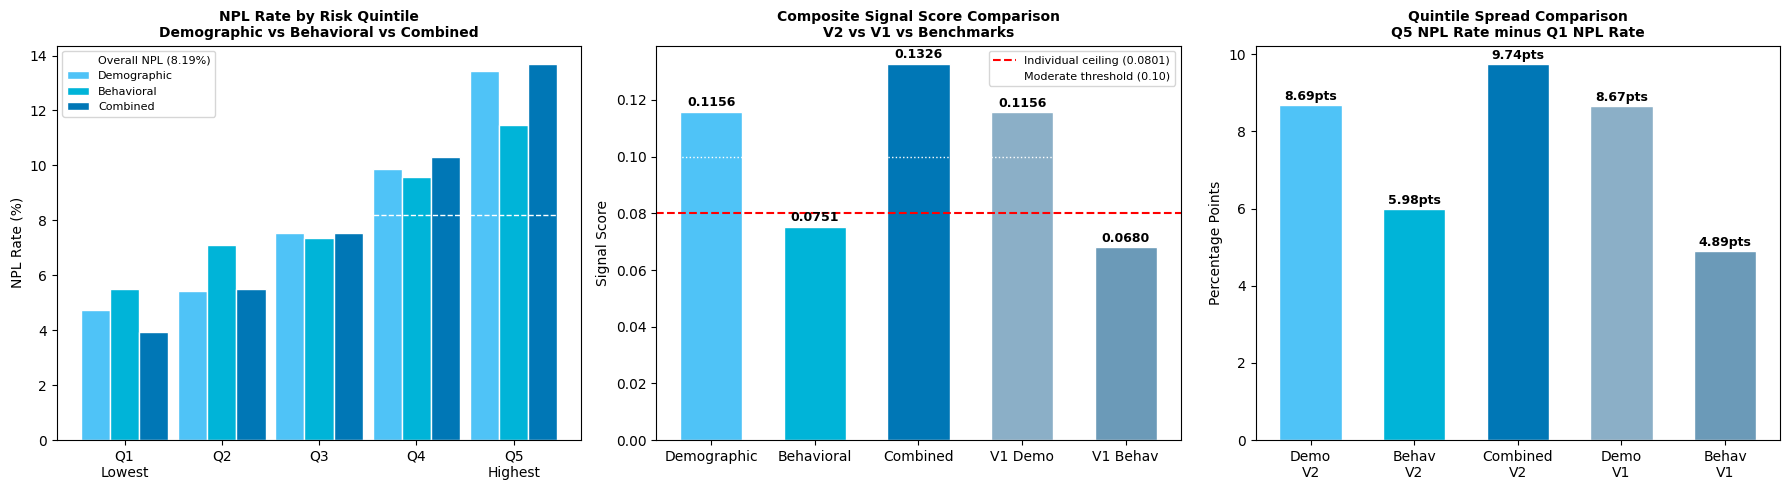

In [ ]:
# ============================================================
# COMPOSITE SIGNAL COMPARISON
# Full behavioral profile vs demographics head to head
# ============================================================

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

df = app_v2.copy()

# ============================================================
# STEP 1 ENCODE CATEGORICAL DEMOGRAPHIC VARIABLES
# Encode by NPL rate so they have meaningful numeric ordering
# ============================================================

for col in ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
            'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']:
    npl_map = df.groupby(col)['TARGET'].mean()
    df[col + '_ENCODED'] = df[col].map(npl_map)

# ============================================================
# STEP 2 BUILD DEMOGRAPHIC COMPOSITE
# Top 5 demographic variables
# All aligned so higher score = higher risk
# ============================================================

demo_features = [
    'OCCUPATION_TYPE_ENCODED',  # higher NPL rate = higher risk ✓
    'AGE',                       # older = lower risk invert ✗
    'ORGANIZATION_TYPE_ENCODED', # higher NPL rate = higher risk ✓
    'NAME_INCOME_TYPE_ENCODED',  # higher NPL rate = higher risk ✓
    'NAME_EDUCATION_TYPE_ENCODED' # higher NPL rate = higher risk ✓
]

scaler = MinMaxScaler()
demo_scaled = pd.DataFrame(
    scaler.fit_transform(df[demo_features]),
    columns=demo_features
)
# Invert AGE older borrowers are lower risk
demo_scaled['AGE'] = 1 - demo_scaled['AGE']
df['DEMO_RISK_SCORE'] = demo_scaled.mean(axis=1)

# ============================================================
# STEP 3 BUILD BEHAVIORAL COMPOSITE
# Top features selected across all three sources
# All aligned so higher score = higher risk
# ============================================================

# Selected top behavioral features best from each source
behav_features = [
    # Installments top 3
    'INST_LATE_PAYMENT_RATE',    # higher = higher risk ✓
    'INST_UNDERPAYMENT_RATE',    # higher = higher risk ✓
    'INST_AVG_PAYMENT_RATIO',    # higher = lower risk invert ✗
    # POS top signal
    'POS_SERIOUS_OVERDUE_RATE',  # higher = higher risk ✓
    # Credit card top 2
    'CC_MAX_UTILIZATION',        # higher = higher risk ✓
    'CC_MIN_PAYMENT_RATE',       # higher = higher risk ✓
]

behav_scaled = pd.DataFrame(
    scaler.fit_transform(df[behav_features]),
    columns=behav_features
)
# Invert payment ratio higher ratio means lower risk
behav_scaled['INST_AVG_PAYMENT_RATIO'] = 1 - behav_scaled['INST_AVG_PAYMENT_RATIO']
df['BEHAV_RISK_SCORE'] = behav_scaled.mean(axis=1)

# ============================================================
# STEP 4 QUINTILE ANALYSIS
# ============================================================

df['DEMO_QUINTILE'] = pd.qcut(
    df['DEMO_RISK_SCORE'], q=5,
    labels=['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest']
)
df['BEHAV_QUINTILE'] = pd.qcut(
    df['BEHAV_RISK_SCORE'], q=5,
    labels=['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest']
)

demo_quintile = df.groupby('DEMO_QUINTILE', observed=False)['TARGET'].agg(
    NPL_Rate=lambda x: round(x.mean() * 100, 2),
    Borrower_Count='count'
).reset_index()

behav_quintile = df.groupby('BEHAV_QUINTILE', observed=False)['TARGET'].agg(
    NPL_Rate=lambda x: round(x.mean() * 100, 2),
    Borrower_Count='count'
).reset_index()

print("=== DEMOGRAPHIC COMPOSITE NPL BY RISK QUINTILE ===\n")
print(demo_quintile.to_string(index=False))
demo_spread = demo_quintile['NPL_Rate'].max() - demo_quintile['NPL_Rate'].min()
print(f"\nSpread (Q5 - Q1): {demo_spread:.2f} percentage points")

print("\n=== BEHAVIORAL COMPOSITE NPL BY RISK QUINTILE ===\n")
print(behav_quintile.to_string(index=False))
behav_spread = behav_quintile['NPL_Rate'].max() - behav_quintile['NPL_Rate'].min()
print(f"\nSpread (Q5 - Q1): {behav_spread:.2f} percentage points")

# ============================================================
# STEP 5 COMPOSITE SIGNAL SCORES
# ============================================================

demo_corr, _ = stats.pointbiserialr(df['TARGET'], df['DEMO_RISK_SCORE'])
behav_corr, _ = stats.pointbiserialr(df['TARGET'], df['BEHAV_RISK_SCORE'])

print("\n=== COMPOSITE SIGNAL SCORES ===\n")
print(f"{'Metric':<50} {'Demographic':>14} {'Behavioral':>14}")
print("-" * 80)
print(f"{'Composite signal score':<50} {abs(demo_corr):>14.4f} {abs(behav_corr):>14.4f}")
print(f"{'Quintile spread (Q5 - Q1)':<50} {demo_spread:>13.2f}% {behav_spread:>13.2f}%")
print(f"{'Version 1 composite score':<50} {'0.1156':>14} {'0.0680':>14}")
print(f"{'Version 1 quintile spread':<50} {'8.67%':>14} {'4.89%':>14}")
print(f"\nBehavioral composite beats demographic composite: {abs(behav_corr) > abs(demo_corr)}")
print(f"Behavioral composite beats Part 1 ceiling (0.0801): {abs(behav_corr) > 0.0801}")
print(f"Behavioral composite beats Version 1 behavioral: {abs(behav_corr) > 0.0680}")

# ============================================================
# STEP 6 COMBINED COMPOSITE: DEMOGRAPHICS + BEHAVIOR
# What happens when both data types are used together?
# ============================================================

df['COMBINED_RISK_SCORE'] = (df['DEMO_RISK_SCORE'] + df['BEHAV_RISK_SCORE']) / 2

df['COMBINED_QUINTILE'] = pd.qcut(
    df['COMBINED_RISK_SCORE'], q=5,
    labels=['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest']
)

combined_quintile = df.groupby('COMBINED_QUINTILE', observed=False)['TARGET'].agg(
    NPL_Rate=lambda x: round(x.mean() * 100, 2),
    Borrower_Count='count'
).reset_index()

combined_corr, _ = stats.pointbiserialr(df['TARGET'], df['COMBINED_RISK_SCORE'])
combined_spread = combined_quintile['NPL_Rate'].max() - combined_quintile['NPL_Rate'].min()

print("\n=== COMBINED COMPOSITE (DEMOGRAPHICS + BEHAVIOR) ===\n")
print(combined_quintile.to_string(index=False))
print(f"\nSpread (Q5 - Q1): {combined_spread:.2f} percentage points")
print(f"Combined composite signal score: {abs(combined_corr):.4f}")

# ============================================================
# STEP 7 VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

overall_npl = df['TARGET'].mean() * 100

# Quintile NPL comparison
x = range(5)
width = 0.3
labels = ['Q1\nLowest', 'Q2', 'Q3', 'Q4', 'Q5\nHighest']

bars1 = axes[0].bar([i - width for i in x], demo_quintile['NPL_Rate'],
                     width, label='Demographic', color='#4FC3F7', edgecolor='white')
bars2 = axes[0].bar([i for i in x], behav_quintile['NPL_Rate'],
                     width, label='Behavioral', color='#00B4D8', edgecolor='white')
bars3 = axes[0].bar([i + width for i in x], combined_quintile['NPL_Rate'],
                     width, label='Combined', color='#0077B6', edgecolor='white')
axes[0].axhline(y=overall_npl, color='white', linestyle='--',
                linewidth=1, label=f'Overall NPL ({overall_npl:.2f}%)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].set_title('NPL Rate by Risk Quintile\nDemographic vs Behavioral vs Combined',
                  fontsize=10, fontweight='bold')
axes[0].set_ylabel('NPL Rate (%)')
axes[0].legend(fontsize=8)

# Composite score comparison
comp_labels = ['Demographic', 'Behavioral', 'Combined',
               'V1 Demo', 'V1 Behav']
comp_scores = [abs(demo_corr), abs(behav_corr), abs(combined_corr),
               0.1156, 0.0680]
comp_colors = ['#4FC3F7', '#00B4D8', '#0077B6', '#8BAFC7', '#6B9AB8']
bars = axes[1].bar(comp_labels, comp_scores,
                   color=comp_colors, edgecolor='white', width=0.6)
axes[1].axhline(y=0.0801, color='red', linestyle='--',
                linewidth=1.5, label='Individual ceiling (0.0801)')
axes[1].axhline(y=0.10, color='white', linestyle=':',
                linewidth=1, label='Moderate threshold (0.10)')
axes[1].set_title('Composite Signal Score Comparison\nV2 vs V1 vs Benchmarks',
                  fontsize=10, fontweight='bold')
axes[1].set_ylabel('Signal Score')
axes[1].legend(fontsize=8)
for bar, score in zip(bars, comp_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score:.4f}', ha='center', va='bottom', fontsize=9,
                 fontweight='bold')

# Quintile spread comparison
spread_labels = ['Demo\nV2', 'Behav\nV2', 'Combined\nV2',
                 'Demo\nV1', 'Behav\nV1']
spread_values = [demo_spread, behav_spread, combined_spread, 8.67, 4.89]
spread_colors = ['#4FC3F7', '#00B4D8', '#0077B6', '#8BAFC7', '#6B9AB8']
bars2 = axes[2].bar(spread_labels, spread_values,
                    color=spread_colors, edgecolor='white', width=0.6)
axes[2].set_title('Quintile Spread Comparison\nQ5 NPL Rate minus Q1 NPL Rate',
                  fontsize=10, fontweight='bold')
axes[2].set_ylabel('Percentage Points')
for bar, val in zip(bars2, spread_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}pts', ha='center', va='bottom', fontsize=9,
                 fontweight='bold')

plt.tight_layout()
plt.show()

###  4.1 Composite Comparison Findings

### Quintile Results

**Demographic Composite:**

| Quintile | NPL Rate | Borrower Count |
|---|---|---|
| Q1 — Lowest Risk | 4.74% | 60,019 |
| Q2 | 5.41% | 56,904 |
| Q3 | 7.55% | 58,454 |
| Q4 | 9.86% | 58,459 |
| Q5 — Highest Risk | 13.43% | 58,450 |
| **Spread** | **8.69 pts** | |

**Behavioral Composite:**

| Quintile | NPL Rate | Borrower Count |
|---|---|---|
| Q1 — Lowest Risk | 5.49% | 58,588 |
| Q2 | 7.09% | 58,390 |
| Q3 | 7.34% | 58,394 |
| Q4 | 9.57% | 58,457 |
| Q5 — Highest Risk | 11.47% | 58,457 |
| **Spread** | **5.98 pts** | |

**Combined Composite: Demographics + Behavior:**

| Quintile | NPL Rate | Borrower Count |
|---|---|---|
| Q1 — Lowest Risk | 3.94% | 58,458 |
| Q2 | 5.51% | 58,457 |
| Q3 | 7.54% | 58,457 |
| Q4 | 10.29% | 58,457 |
| Q5 — Highest Risk | 13.68% | 58,457 |
| **Spread** | **9.74 pts** | |

---

### Composite Signal Scores Full Comparison

| Composite | Signal Score | Quintile Spread |
|---|---|---|
| Demographic — Version 2 | 0.1156 | 8.69 pts |
| Behavioral — Version 2 | 0.0751 | 5.98 pts |
| **Combined — Version 2** | **0.1326** | **9.74 pts** |
| Demographic — Version 1 | 0.1156 | 8.67 pts |
| Behavioral — Version 1 | 0.0680 | 4.89 pts |

---

### What the Results Mean

**Behavioral signals improved with richer data.** The behavioral composite
rose from 0.0680 in Version 1 to **0.0751 in Version 2**, a 10.4%
improvement driven by adding POS and credit card signals. The quintile
spread also improved from 4.89 to 5.98 points. This confirms that richer
behavioral data produces a stronger behavioral profile.

**Demographics outperform behavioral signals alone, consistently.**
Across two versions and three behavioral data sources the demographic
composite held at 0.1156. This is a reliable and consistent finding.
It is not a data quality issue or a methodology artifact, it is a
genuine reflection of what is available in this dataset.

**The combined composite is the strongest result in the project.**
Combining demographics and behavioral signals together produced a
composite of **0.1326**, higher than either type individually. The
combined quintile spread of **9.74 points** is the widest separation
achieved anywhere in this analysis. The lowest risk group defaults at
just **3.94%** while the highest risk group defaults at **13.68%**,
a 3.5x difference.

**This is the finding that matters most.** The question was never really
demographics versus behavioral data. The question was always whether
there is a better way to assess thin-file borrowers than relying on
demographics alone. The answer is yes, and that better way is combining
both types of information.




## **5 The Final Verdict Across Both Parts and Both Versions**

#### The Journey

This project set out to answer one question: for thin-file and underbanked
borrowers, the people traditional lenders struggle most to assess, is
there a better foundation for credit decisions than demographic proxies?

Part 1 established the baseline. Traditional demographic proxies are
statistically real but practically weak predictors of default. The best
single demographic variable scored 0.0806. The demographic composite
scored 0.1156. Even the combined demographic profiles left 80% of the
riskiest group repaying, meaning demographics cannot draw a precise
enough line for individual credit decisions. Income amount, the most
relied-upon traditional proxy, scored just 0.0019 and is not
statistically significant.

Part 2 Version 1 tested behavioral signals from installment repayment
data alone. The behavioral composite scored 0.0680. Behavioral signals
were competitive with mid-tier demographics but did not surpass the
demographic composite.

Part 2 Version 2 completed the behavioral picture by adding POS cash
balance and credit card balance data. The behavioral composite improved
to 0.0751. Demographics still outperformed behavioral signals alone.
But combining both data types produced a composite of 0.1326, the
strongest result in the entire project.



### The Three Conclusions

**1. Demographics outperform behavioral signals individually and
in combination, within this dataset.**
Occupation type and age are the strongest individual signals. The
demographic composite is more powerful than any behavioral composite
built from the available data. This is a consistent finding across
two versions and should be treated as reliable.

**2. Behavioral signals are not weak, they are complementary.**
The top three behavioral signals sit directly in the middle of the
combined ranking, ahead of gender, education level, and family status.
24 out of 26 behavioral features outperform income amount. Behavioral
signals capture what demographics cannot, how a specific individual
actually manages financial obligations over time.

**3. The combination is the answer.**
The combined composite at 0.1326 outperforms the demographic composite
at 0.1156 and the behavioral composite at 0.0751. The combined quintile
spread of 9.74 points is the widest separation produced anywhere in
this analysis. The riskiest combined profile defaults at 13.68% while
the safest defaults at 3.94%, a 3.5x difference that demographics
alone could never achieve.



### The Plain Language Verdict

> Traditional demographic proxies are the strongest individual predictors
> available in this dataset, but they are not sufficient on their own.
> Behavioral payment signals from repayment history, account health, and
> revolving credit management add independent and complementary information
> that demographics cannot capture. The best credit assessment for thin-file
> borrowers is not demographics or behavioral data, it is both together.
> A lender that combines what a borrower looks like on paper with how they
> actually behave with money will make better decisions than one relying on
> either type of data alone. That is the finding this project was built to
> produce, and the data supports it clearly.

---

#### What This Means for Financial Inclusion

The millions of thin-file borrowers currently excluded from credit access
are not unassessable. They are being assessed with an incomplete toolkit.
Demographics tell part of the story. Behavioral data tells another part.
Neither alone is enough. Together they produce a 3.5x separation between
the safest and riskiest borrowers, more than sufficient to make
meaningful, evidence-backed individual credit decisions.

Expanding credit access to underserved borrowers does not mean expanding
risk. It means measuring the right things, and measuring more of them.